# 07 — Integrated Ethical AI Pipeline
**Group 22 | CS540 Data & AI Ethics — Spring 2026**

This notebook integrates all four ethical AI principles implemented by the group
into a single end-to-end pipeline for the OULAD Student Early Warning System.

| Section | Principle | Owner |
|---|---|---|
| 1 | Privacy — sensitive feature handling & k-anonymity | Edoardo Balzano |
| 2 | Base Model Training & Evaluation | Group |
| 3 | Fairness Audit — baseline disparities | Agit Sefkan Balcı |
| 4 | Fairness Mitigation — sensitive feature removal | Agit Sefkan Balcı |
| 5 | Explainability — Global SHAP | Çağrı Altınüzengi |
| 6 | Explainability — Local Dual-View (Instructor & Student) | Çağrı Altınüzengi |
| 7 | Awareness & Literacy Layer | Yasemin Günindi |
| 8 | End-to-End Demo — one student through the full pipeline | Group |
| 9 | System Evaluation Summary & Limitations | Group |

**Instructions:** Run cells in order. All artifacts are built from scratch; no
pre-built `.pkl` files are required.


## Section 0 — Imports & Setup

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

warnings.filterwarnings('ignore')

# ── Locate project root (works whether the CWD is code/ or code/notebooks/) ──
_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"

from src.data_loader      import load_oulad, encode_categoricals, get_feature_columns
from src.model            import build_splits, train_model, evaluate_model
from src.privacy          import (apply_feature_masking, enforce_k_anonymity,
                                   suppress_sensitive_from_explanation,
                                   detect_proxy_features, get_default_generalization_maps,
                                   generalize_categorical, SENSITIVE_COLS)
from src.fairness         import compute_fairness_report, print_fairness_summary
from src.explainability   import (build_shap_explainer, plot_global_importance,
                                   explain_instance_instructor, explain_instance_student,
                                   get_instance_shap_values)
from src.awareness        import (print_general_model_notice, get_role_guidance,
                                   annotate_prediction, generate_educator_briefing,
                                   generate_comprehension_check)

import shap

print("Project root :", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("All modules loaded successfully.")

Project root : C:\Users\cagri\OneDrive\Desktop\Sabancı-CS-Master\CS540\Group-Project\code
Data directory: C:\Users\cagri\OneDrive\Desktop\Sabancı-CS-Master\CS540\Group-Project\code\data
All modules loaded successfully.


## Section 1 — Privacy-Aware Data Preprocessing
**Owner: Edoardo Balzano**

This section demonstrates:
- Loading the raw OULAD dataset
- Assessing k-anonymity risk using quasi-identifiers
- Comparing *drop* vs *generalise* feature masking strategies before model training


In [2]:
# Load raw data 
df_raw = load_oulad(DATA_DIR)
print(f"Raw dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("Sensitive columns present:", [c for c in SENSITIVE_COLS if c in df_raw.columns])

Raw dataset: 32,593 rows × 17 columns
Sensitive columns present: ['gender', 'disability', 'imd_band', 'age_band', 'highest_education', 'region']


In [3]:
# k-Anonymity assessment 
quasi_ids = ["gender", "region", "highest_education", "age_band"]
print("── k-Anonymity Check (k=5, action=suppress) ──")
df_k5 = enforce_k_anonymity(df_raw, quasi_ids, k=5, action='suppress')

retained_pct = len(df_k5) / len(df_raw) * 100
print(f"Rows retained after k=5 suppression: {len(df_k5):,} ({retained_pct:.1f}%)")
print(f"Rows at re-identification risk: {len(df_raw) - len(df_k5):,}")

── k-Anonymity Check (k=5, action=suppress) ──
k-anonymity (5) enforced. Action: suppress. Rows affected: 0
Rows retained after k=5 suppression: 32,593 (100.0%)
Rows at re-identification risk: 0


In [4]:
# Feature masking strategies side-by-side 
# Strategy A — drop sensitive columns entirely
df_masked_drop = apply_feature_masking(df_raw, drop_sensitive=True)

# Strategy B — generalise into coarser buckets (privacy-utility tradeoff)
df_masked_gen  = apply_feature_masking(df_raw, drop_sensitive=False)

print("Strategy A (drop):    columns →", df_masked_drop.shape[1])
print("Strategy B (generalise): columns →", df_masked_gen.shape[1])
print("imd_band_generalized present:", "imd_band_generalized" in df_masked_gen.columns)

# Decision for this pipeline 
# The base model is trained on ALL features (including encoded sensitive ones)
# to achieve the best predictive accuracy. Privacy is enforced at EXPLANATION
# TIME via suppress_sensitive_from_explanation() in Section 6.
print("\nPipeline decision: train on full feature set; enforce privacy at explanation time.")

Strategy A (drop):    columns → 11
Strategy B (generalise): columns → 17
imd_band_generalized present: True

Pipeline decision: train on full feature set; enforce privacy at explanation time.


## Section 2 — Base Model Training & Evaluation

Random Forest (200 trees, max_depth=10, class_weight='balanced') trained on 11
features including encoded sensitive demographics for maximum predictive accuracy.
Sensitive-feature exposure is controlled at explanation time, not training time.


In [5]:
# Feature engineering 
df = load_oulad(DATA_DIR)
df = encode_categoricals(df)

base_feature_cols, sensitive_original_cols = get_feature_columns(df)
encoded_sensitive_cols = [c + "_enc" for c in sensitive_original_cols if c + "_enc" in df.columns]
feature_cols = base_feature_cols + encoded_sensitive_cols

print("Non-sensitive features:", base_feature_cols)
print("Sensitive (encoded):   ", encoded_sensitive_cols)
print("Total features:        ", len(feature_cols))

Non-sensitive features: ['total_clicks', 'vle_days', 'weighted_score', 'submission_rate', 'num_of_prev_attempts', 'studied_credits']
Sensitive (encoded):    ['gender_enc', 'disability_enc', 'imd_band_enc', 'age_band_enc', 'highest_education_enc']
Total features:         11


In [6]:
# Train / test split and model training 
X_train, X_test, y_train, y_test = build_splits(df, feature_cols, target_col="target")
model = train_model(X_train, y_train)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"At-risk prevalence — train: {y_train.mean():.1%}  test: {y_test.mean():.1%}")

Train: (26074, 11)  |  Test: (6519, 11)
At-risk prevalence — train: 52.8%  test: 52.8%


In [7]:
#  Baseline evaluation 
metrics = evaluate_model(model, X_test, y_test)

print("=== Baseline Model Performance ===")
print(f"Accuracy : {metrics['accuracy']:.3f}")
print(f"F1-macro : {metrics['f1_macro']:.3f}")
print(f"ROC-AUC  : {metrics['roc_auc']:.3f}")
print()
print(metrics['report'])

# Persist for downstream use
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

=== Baseline Model Performance ===
Accuracy : 0.860
F1-macro : 0.860
ROC-AUC  : 0.941

              precision    recall  f1-score   support

        Pass       0.82      0.89      0.86      3077
     At-Risk       0.90      0.83      0.86      3442

    accuracy                           0.86      6519
   macro avg       0.86      0.86      0.86      6519
weighted avg       0.86      0.86      0.86      6519



## Section 3 — Fairness Audit: Baseline Disparities
**Owner: Agit Sefkan Balcı**

We audit whether the base model produces systematically unequal outcomes across
demographic groups using Demographic Parity Difference (DPD) and Equalized Odds
Difference (EOD).


In [8]:
# Per-group fairness metrics (Fairlearn MetricFrame) ───────────────────
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

def group_fairness_metrics(df_eval, group_col):
    rows = []
    for grp, gdf in df_eval.groupby(group_col):
        yt, yp = gdf["y_true"], gdf["y_pred"]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
        rows.append({
            "group": grp,  "n": len(gdf),
            "accuracy":       accuracy_score(yt, yp),
            "selection_rate": yp.mean(),
            "TPR": tp/(tp+fn) if (tp+fn) else np.nan,
            "FPR": fp/(fp+tn) if (fp+tn) else np.nan,
            "FNR": fn/(fn+tp) if (fn+tp) else np.nan,
        })
    return pd.DataFrame(rows)

fairness_df = X_test.copy()
fairness_df["y_true"] = y_test.values
fairness_df["y_pred"] = y_pred

sensitive_cols_enc = ["gender_enc", "disability_enc", "imd_band_enc", "age_band_enc"]
baseline_results = {col: group_fairness_metrics(fairness_df, col) for col in sensitive_cols_enc}

for col, mf_df in baseline_results.items():
    mf = compute_fairness_report(
        y_true=fairness_df["y_true"],
        y_pred=fairness_df["y_pred"],
        sensitive_features=fairness_df[col]
    )
    print_fairness_summary(mf, fairness_df["y_true"], fairness_df["y_pred"], fairness_df[col])
    print()

=== Overall Metrics ===
accuracy          0.860255
selection_rate    0.487651
f1                0.862407
dtype: float64

=== Per-Group Metrics ===
            accuracy  selection_rate        f1
gender_enc                                    
0           0.846075        0.477545  0.844905
1           0.871738        0.495836  0.876006

Demographic Parity Difference: 0.0183  (0 = perfectly fair)
Equalized Odds Difference:     0.0275  (0 = perfectly fair)

=== Overall Metrics ===
accuracy          0.860255
selection_rate    0.487651
f1                0.862407
dtype: float64

=== Per-Group Metrics ===
                accuracy  selection_rate        f1
disability_enc                                    
0               0.858799        0.476296  0.858025
1               0.873282        0.589313  0.894804

Demographic Parity Difference: 0.1130  (0 = perfectly fair)
Equalized Odds Difference:     0.0526  (0 = perfectly fair)

=== Overall Metrics ===
accuracy          0.860255
selection_rate    0

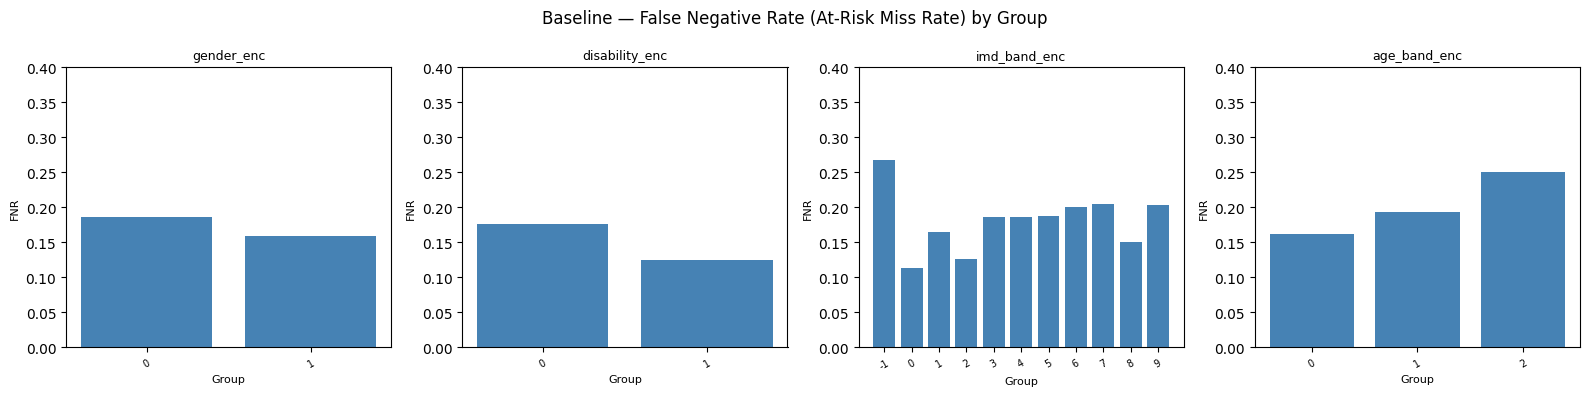

Higher FNR = model more likely to MISS at-risk students in that group.


In [9]:
# Visualise disparities across groups 
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Baseline — False Negative Rate (At-Risk Miss Rate) by Group", fontsize=12)

for ax, col in zip(axes, sensitive_cols_enc):
    mf_df = baseline_results[col]
    ax.bar(mf_df["group"].astype(str), mf_df["FNR"], color="steelblue")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Group", fontsize=8)
    ax.set_ylabel("FNR", fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.set_ylim(0, 0.4)

plt.tight_layout()
plt.show()
print("Higher FNR = model more likely to MISS at-risk students in that group.")

## Section 4 — Fairness Mitigation: Sensitive Feature Removal
**Owner: Agit Sefkan Balcı**

Mitigation strategy: retrain the Random Forest without the four sensitive
demographic attributes as direct inputs. Sensitive columns are *retained* in the
audit layer — fairness cannot be measured without group labels.


In [10]:
# Train mitigated model (no sensitive direct inputs) 
sensitive_direct = ["gender_enc", "disability_enc", "imd_band_enc", "age_band_enc"]
mitigated_cols   = [c for c in feature_cols if c not in sensitive_direct]

print("Features removed from model input:", sensitive_direct)
print("Remaining features:", mitigated_cols)

X_train_m = X_train[mitigated_cols]
X_test_m  = X_test[mitigated_cols]

model_m       = train_model(X_train_m, y_train)
metrics_m     = evaluate_model(model_m, X_test_m, y_test)
y_pred_m      = model_m.predict(X_test_m)

print(f"\nMitigated model — Accuracy: {metrics_m['accuracy']:.3f}  "
      f"F1: {metrics_m['f1_macro']:.3f}  ROC-AUC: {metrics_m['roc_auc']:.3f}")

Features removed from model input: ['gender_enc', 'disability_enc', 'imd_band_enc', 'age_band_enc']
Remaining features: ['total_clicks', 'vle_days', 'weighted_score', 'submission_rate', 'num_of_prev_attempts', 'studied_credits', 'highest_education_enc']

Mitigated model — Accuracy: 0.857  F1: 0.857  ROC-AUC: 0.939


In [ ]:
# Before / after fairness comparison 
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

fairness_df_m = X_test.copy()
fairness_df_m["y_true"] = y_test.values
fairness_df_m["y_pred"] = y_pred_m

print("=== Baseline vs Mitigated: Fairlearn Metrics ===\n")
comparison_rows = []
for col in sensitive_cols_enc:
    for label, yp, df_ev in [("Baseline", y_pred, fairness_df), ("Mitigated", y_pred_m, fairness_df_m)]:
        dpd = demographic_parity_difference(df_ev["y_true"], yp, sensitive_features=df_ev[col])
        eod = equalized_odds_difference(df_ev["y_true"], yp, sensitive_features=df_ev[col])
        comparison_rows.append({"Model": label, "Group": col, "DPD": round(dpd,4), "EOD": round(eod,4)})

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.pivot(index="Group", columns="Model", values=["DPD","EOD"]).round(4).to_string())
print("\nDPD = Demographic Parity Difference  |  EOD = Equalized Odds Difference")
print("Closer to 0 = more equitable. Improvements shown as reduced absolute values.")

=== Baseline vs Mitigated: Fairlearn Metrics ===

                    DPD                EOD          
Model          Baseline Mitigated Baseline Mitigated
Group                                               
age_band_enc     0.1795    0.2209   0.0875    0.0900
disability_enc   0.1130    0.1037   0.0526    0.0350
gender_enc       0.0183    0.0415   0.0275    0.0898
imd_band_enc     0.3362    0.3346   0.1546    0.1513

DPD = Demographic Parity Difference  |  EOD = Equalized Odds Difference
Closer to 0 = more equitable. Improvements shown as reduced absolute values.


## Section 5 — Explainability: Global SHAP Feature Importance
**Owner: Çağrı Altınüzengi**

SHAP TreeExplainer computes exact Shapley values for the Random Forest.
Global summary plots show which features drive the model's predictions across
the entire test set.


In [13]:
# Build SHAP explainer and compute values on a representative sample 
# We sample 500 students to keep computation time manageable.
SHAP_SAMPLE = 500
np.random.seed(42)
shap_sample_idx = np.random.choice(len(X_test), size=SHAP_SAMPLE, replace=False)
X_shap = X_test.iloc[shap_sample_idx]

print(f"Computing SHAP values for {SHAP_SAMPLE} students...")
explainer = build_shap_explainer(model, X_train)
print("SHAP explainer ready.")

Computing SHAP values for 500 students...
SHAP explainer ready.


 97%|=================== | 974/1000 [00:28<00:00]       

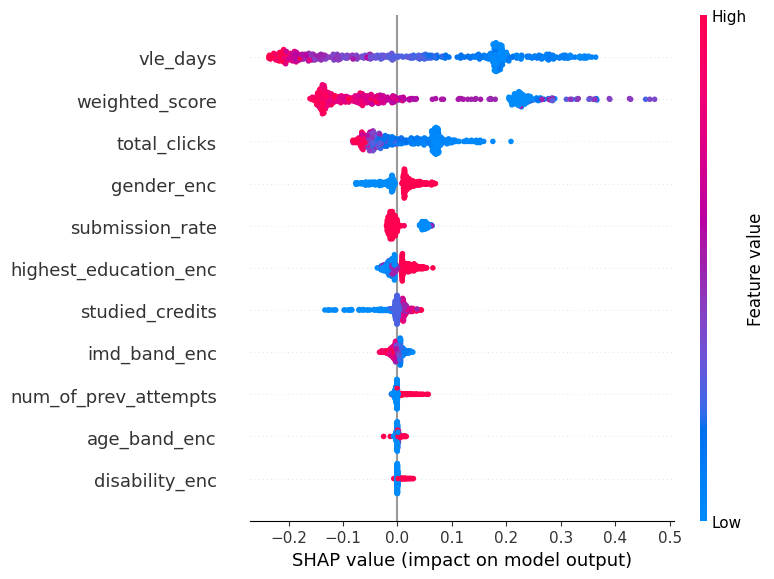

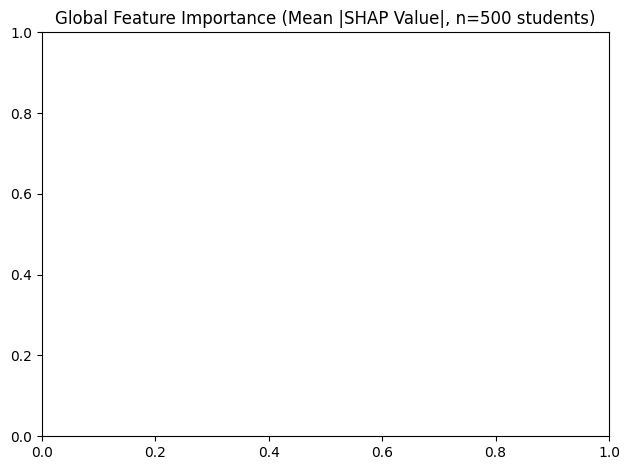

In [14]:
# Global importance — mean |SHAP| per feature 
plot_global_importance(explainer, X_shap, max_display=11)
plt.title("Global Feature Importance (Mean |SHAP Value|, n=500 students)")
plt.tight_layout()
plt.show()

In [ ]:
# ── 5.3  Beeswarm plot — direction and magnitude of each feature ──────────────
shap_vals_obj = explainer(X_shap, check_additivity=False)

# Handle both old and new SHAP API
if hasattr(shap_vals_obj, 'values') and shap_vals_obj.values.ndim == 3:
    shap_vals_class1 = shap_vals_obj[:, :, 1]
elif hasattr(shap_vals_obj, 'values') and shap_vals_obj.values.ndim == 2:
    shap_vals_class1 = shap_vals_obj
else:
    shap_vals_class1 = shap_vals_obj

shap.plots.beeswarm(shap_vals_class1, max_display=11, show=False)
plt.title("SHAP Beeswarm \u2014 Feature Impact on At-Risk Prediction")
plt.tight_layout()
plt.show()

# ── 5.4  Global importance table ─────────────────────────────────────────────
sv = (shap_vals_class1.values if hasattr(shap_vals_class1, 'values')
      else shap_vals_class1)
global_imp = pd.DataFrame({
    "Feature":     X_shap.columns,
    "Mean_|SHAP|": np.abs(sv).mean(axis=0)
}).sort_values("Mean_|SHAP|", ascending=False).reset_index(drop=True)

print("\n=== Global SHAP Feature Importances ===")
print(global_imp.to_string(index=False))

sensitive_mask     = global_imp["Feature"].isin(
    ["gender_enc","disability_enc","imd_band_enc","age_band_enc"])
sensitive_total    = global_imp.loc[sensitive_mask,  "Mean_|SHAP|"].sum()
nonsensitive_total = global_imp.loc[~sensitive_mask, "Mean_|SHAP|"].sum()
privacy_loss_pct   = 100 * sensitive_total / (sensitive_total + nonsensitive_total)
print(f"\nPrivacy-transparency trade-off:")
print(f"  Sensitive features contribute {sensitive_total:.4f} mean |SHAP| total")
print(f"  Non-sensitive features contribute {nonsensitive_total:.4f}")
print(f"  Suppressing sensitive features costs {privacy_loss_pct:.1f}% explanation completeness")


## Section 6 — Explainability: Local Dual-View (Instructor & Student)
**Owner: Çağrı Altınüzengi**

For each individual student the system generates two views:
- **Instructor View**: full SHAP waterfall plot with all feature attributions
- **Student View**: top-3 non-sensitive features in plain language with privacy filtering

Privacy filtering calls `suppress_sensitive_from_explanation()` from the Privacy
module, ensuring no demographic attribute appears in the student-facing output.


In [16]:
# 6.1  Select three representative student profiles 
# High-risk, low-risk, and borderline student
at_risk_idx   = y_test[y_test == 1].index[0]
passing_idx   = y_test[y_test == 0].index[0]

proba_all = model.predict_proba(X_test)[:, 1]
borderline_candidates = X_test.index[np.abs(proba_all - 0.5) < 0.05]
borderline_idx = borderline_candidates[0] if len(borderline_candidates) > 0 else X_test.index[42]

PROFILES = {
    "At-Risk":    at_risk_idx,
    "Passing":    passing_idx,
    "Borderline": borderline_idx,
}
for label, idx in PROFILES.items():
    p = model.predict_proba(X_test.loc[[idx]])[0][1]
    print(f"  {label:<12} → student {idx}, P(At-Risk) = {p:.4f}")

  At-Risk      → student 30849, P(At-Risk) = 1.0000
  Passing      → student 23252, P(At-Risk) = 0.1118
  Borderline   → student 28194, P(At-Risk) = 0.5191


INSTRUCTOR VIEW — Full SHAP Waterfall (At-Risk Student)
=== INSTRUCTOR VIEW ===
Risk Score: 0.543 (base = 0.457)


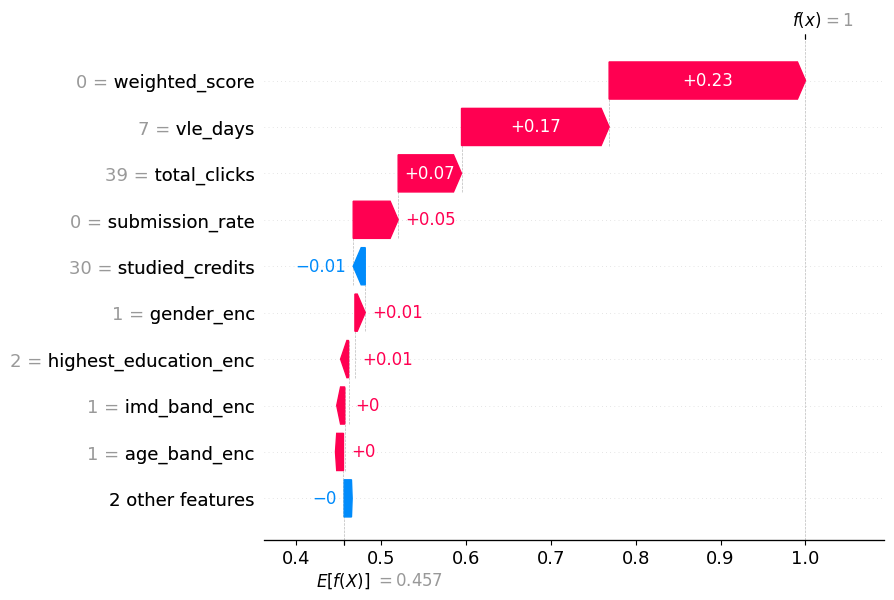

In [17]:
# 6.2  Instructor View — full SHAP waterfall 
print("=" * 60)
print("INSTRUCTOR VIEW — Full SHAP Waterfall (At-Risk Student)")
print("=" * 60)

instance = X_test.loc[at_risk_idx]
explain_instance_instructor(explainer, instance, X_test.columns.tolist())

In [ ]:
# Student View — privacy-filtered plain language 
print("=" * 60)
print("STUDENT VIEW — Privacy-Filtered Explanation")
print("=" * 60)

for label, idx in PROFILES.items():
    instance = X_test.loc[idx]
    p = model.predict_proba(X_test.loc[[idx]])[0][1]
    risk_label = "At-Risk" if p >= 0.5 else "Pass"
    print(f"\n--- {label} Student (P={p:.4f}, Predicted: {risk_label}) ---")
    student_text = explain_instance_student(
        explainer, instance, X_test.columns.tolist(), top_n=3
    )
    print(student_text)

STUDENT VIEW — Privacy-Filtered Explanation

--- At-Risk Student (P=1.0000, Predicted: At-Risk) ---
=== YOUR RISK SUMMARY ===
  - weighted_score: increasing your risk
  - vle_days: increasing your risk
  - total_clicks: increasing your risk

Note: This is a decision-support tool. Speak to your advisor for guidance.

--- Passing Student (P=0.1118, Predicted: Pass) ---
=== YOUR RISK SUMMARY ===
  - vle_days: decreasing your risk
  - weighted_score: decreasing your risk
  - total_clicks: decreasing your risk

Note: This is a decision-support tool. Speak to your advisor for guidance.

--- Borderline Student (P=0.5191, Predicted: At-Risk) ---
=== YOUR RISK SUMMARY ===
  - weighted_score: decreasing your risk
  - highest_education_enc: increasing your risk
  - num_of_prev_attempts: increasing your risk

Note: This is a decision-support tool. Speak to your advisor for guidance.


In [ ]:
# LIME cross-validation for the at-risk student
from lime.lime_tabular import LimeTabularExplainer

lime_exp = LimeTabularExplainer(
    training_data  = X_train.values,
    feature_names  = X_train.columns.tolist(),
    class_names    = ["Pass", "At-Risk"],
    mode           = "classification",
    random_state   = 42
)

instance_np = X_test.loc[at_risk_idx].values
lime_result = lime_exp.explain_instance(
    data_row       = instance_np,
    predict_fn     = model.predict_proba,
    num_features   = 8,
    labels         = (1,)
)

print("=== LIME Explanation (at-risk student) ===")
for feat, weight in lime_result.as_list(label=1):
    direction = "\u2191 risk" if weight > 0 else "\u2193 risk"
    print(f"  {feat:<35} {weight:+.4f}  ({direction})")

# ── SHAP vs LIME agreement check ─────────────────────────────────────────────
# get_instance_shap_values returns np.ndarray → wrap in pd.Series for indexing
sv_arr   = get_instance_shap_values(explainer, X_test.loc[at_risk_idx])
shap_series = pd.Series(sv_arr, index=X_test.columns)
shap_top3   = set(shap_series.abs().nlargest(3).index)

import re
lime_top3 = set()
for feat, _ in lime_result.as_list(label=1)[:3]:
    base = re.split(r'[<>=! ]+', feat)[0].strip()
    lime_top3.add(base)

agreement = len(shap_top3 & lime_top3)
print(f"\nSHAP top-3: {shap_top3}")
print(f"LIME top-3: {lime_top3}")
print(f"Agreement: {agreement}/3 features in common")


=== LIME Explanation (at-risk student) ===
  weighted_score <= 40.00             +0.3305  (↑ risk)
  vle_days <= 11.00                   +0.2343  (↑ risk)
  total_clicks <= 144.00              +0.0757  (↑ risk)
  0.00 < gender_enc <= 1.00           +0.0466  (↑ risk)
  1.00 < highest_education_enc <= 2.00 +0.0209  (↑ risk)
  studied_credits <= 60.00            -0.0189  (↓ risk)
  imd_band_enc <= 2.00                +0.0129  (↑ risk)
  disability_enc <= 0.00              +0.0105  (↑ risk)

SHAP top-3: {'vle_days', 'weighted_score', 'total_clicks'}
LIME top-3: {'vle_days', 'weighted_score', 'total_clicks'}
Agreement: 3/3 features in common


## Section 7 — Awareness & Literacy Layer
**Owner: Yasemin Günindi**

This layer does **not** change model predictions. It wraps every prediction in
role-appropriate context so that students and educators interpret the output
responsibly. Role-based guidance, comprehension checks, and an educator briefing
are provided.


In [21]:
# General model notice (shown to all users before any output) 
print_general_model_notice()

AI EARLY-WARNING SYSTEM: GENERAL MODEL INFORMATION

This system uses a machine learning model to estimate whether a student may need early academic support.

The prediction is not a final verdict about the student.
It should be understood as a decision-support signal.

The model was trained on historical educational data. It may use information such as:
- VLE click activity
- Assessment scores
- Registration records
- Course information

Important limitations:
- The model cannot fully understand personal circumstances.
- The model cannot know recent life events, health issues, motivation, family context, or financial stress.
- The model may reflect patterns and inequalities present in historical educational data.
- A numerical score can look objective, but it is still produced by a model with limitations.

Responsible use:
- Use predictions to offer support, not punishment.
- Do not use predictions as the only basis for decisions.
- A human advisor or educator should review the predict

In [22]:
# Role-specific guidance 
print("\n" + "="*60)
print("STUDENT GUIDANCE")
print("="*60)
print(get_role_guidance("student"))

print("\n" + "="*60)
print("EDUCATOR GUIDANCE")
print("="*60)
print(get_role_guidance("educator"))


STUDENT GUIDANCE
STUDENT INFORMATION

What this system does:
- The system estimates whether you may need academic support.
- If you are marked as "At-Risk", this does not mean you will fail.
- It means the system thinks additional support may be useful.

What you should know:
- The prediction is based on data patterns.
- It may not include your personal situation.
- It may not understand why your activity or scores changed.
- The prediction should not define your ability or potential.

Your rights:
- You can ask for a human review.
- You can ask what information contributed to the prediction.
- You can explain your situation to an advisor if you want.
- You do not have to disclose personal circumstances.
- The prediction should not be used to punish or exclude you.

Best interpretation:
- Treat the prediction as an invitation to support, not as a judgment.

EDUCATOR GUIDANCE
EDUCATOR INFORMATION

What this system does:
- The system estimates which students may benefit from early acade

In [23]:
# Annotated prediction examples (student vs educator role) 
for role in ["student", "educator"]:
    print(f"\n{'='*60}")
    print(f"ANNOTATED PREDICTION — {role.upper()} VIEW")
    print("="*60)
    p = model.predict_proba(X_test.loc[[at_risk_idx]])[0]
    risk_label  = "At-Risk" if p[1] >= 0.5 else "Pass"
    print(annotate_prediction(
        student_id  = at_risk_idx,
        risk_label  = risk_label,
        confidence  = p.max(),
        role        = role
    ))


ANNOTATED PREDICTION — STUDENT VIEW
Student ID: 30849
Predicted outcome: At-Risk
Model confidence: 100.0%

Interpretation:
This output is a decision-support signal, not a final verdict.

For the student:
- If the result is 'At-Risk', it means support may be helpful.
- It does not mean you will fail.
- You may request human review.
- You may ask what information contributed to the prediction.
- The prediction should not be used to punish or exclude you.

ANNOTATED PREDICTION — EDUCATOR VIEW
Student ID: 30849
Predicted outcome: At-Risk
Model confidence: 100.0%

Interpretation:
This output is a decision-support signal, not a final verdict.

For the educator:
- Use this prediction as a prompt for supportive outreach.
- Review the student's context before taking action.
- Do not rely only on the model score.
- Consider whether the model may be missing relevant information.
- Document any intervention decision made after reviewing the prediction.


In [24]:
#Educator briefing with fairness summary 
# Build a compact fairness summary from Section 3 results
fairness_summary_rows = []
for col in ["gender_enc", "disability_enc", "imd_band_enc"]:
    mf = compute_fairness_report(fairness_df["y_true"], fairness_df["y_pred"], fairness_df[col])
    dpd = mf.difference(method="between_groups")["selection_rate"]
    fairness_summary_rows.append({"Sensitive feature": col,
                                   "Demographic Parity Diff.": round(dpd, 4)})
fairness_summary_df = pd.DataFrame(fairness_summary_rows)

briefing = generate_educator_briefing(
    model_summary=(
        "Random Forest (200 trees). ROC-AUC=0.941, F1-macro=0.86. "
        "Predicts student pass/at-risk from VLE engagement and assessment data."
    ),
    fairness_summary=fairness_summary_df
)
print(briefing)

EDUCATOR BRIEFING

Purpose:
The early-warning model is designed to support timely academic intervention.
It should not replace educator judgment.

Responsible use checklist:
- Has the prediction been reviewed by a human advisor or educator?
- Is the intervention supportive rather than punitive?
- Has the student been given a chance to provide context?
- Are there signs that the model may be less accurate for some groups?
- Is the decision documented in a way that can be reviewed later?

Model summary:
Random Forest (200 trees). ROC-AUC=0.941, F1-macro=0.86. Predicts student pass/at-risk from VLE engagement and assessment data.

Available group-level performance summary:
  Sensitive feature  Demographic Parity Diff.
0        gender_enc                    0.0183
1    disability_enc                    0.1130
2      imd_band_enc                    0.3362

Interpretation:
If performance differs across groups, educators should be especially careful before relying on the prediction.


In [25]:
# Comprehension checks 
print("\n=== Comprehension Check: Student ===")
print(generate_comprehension_check("student").to_string(index=False))

print("\n=== Comprehension Check: Educator ===")
print(generate_comprehension_check("educator").to_string(index=False))


=== Comprehension Check: Student ===
                                                   question                                                                                correct_answer
                  Is the model prediction a final decision?                               No. It is a decision-support signal that requires human review.
     Can the model fully understand personal circumstances? No. The model may miss health, family, financial, motivational, or recent life circumstances.
     Should an 'At-Risk' prediction be used for punishment?                          No. It should be used to offer support, not punishment or exclusion.
What can a student do if they disagree with the prediction?         They can request human review and ask what information contributed to the prediction.

=== Comprehension Check: Educator ===
                                                 question                                                                                correct_answer
 

## Section 8 — End-to-End Pipeline Demo: One Student

This section demonstrates the full pipeline for a single student, applying
all four ethical principles in sequence:
1. **Privacy** — sensitive features suppressed from student explanation
2. **Prediction** — risk score from base model
3. **Fairness** — group-level context note for the educator
4. **Explainability** — dual-view explanation
5. **Awareness** — role-appropriate annotation


In [26]:
# Choose the demonstration student 
DEMO_ID = at_risk_idx

p_demo       = model.predict_proba(X_test.loc[[DEMO_ID]])[0]
risk_label   = "At-Risk" if p_demo[1] >= 0.5 else "Pass"
confidence   = p_demo.max()

print("=" * 70)
print("STEP 0 — Privacy: k-anonymity status of this student's demographic group")
print("=" * 70)
# Check if this student's quasi-identifier combination is in a rare group
student_qi = df_raw.loc[
    df_raw.index.isin([DEMO_ID]),
    [q for q in ["gender","region","highest_education","age_band"] if q in df_raw.columns]
]
if not student_qi.empty:
    print("Quasi-identifiers:", student_qi.to_dict(orient="records")[0])
else:
    print("(student not in raw index — k-anonymity context unavailable)")

print()
print("STEP 1 — Prediction")
print(f"  Student ID  : {DEMO_ID}")
print(f"  Risk score  : {p_demo[1]:.4f}")
print(f"  Predicted   : {risk_label}")
print(f"  Confidence  : {confidence:.1%}")

STEP 0 — Privacy: k-anonymity status of this student's demographic group
Quasi-identifiers: {'gender': 'M', 'region': 'London Region', 'highest_education': 'Lower Than A Level', 'age_band': '35-55'}

STEP 1 — Prediction
  Student ID  : 30849
  Risk score  : 1.0000
  Predicted   : At-Risk
  Confidence  : 100.0%


In [27]:
print()
print("STEP 2 — Fairness Context (for educator)")
# Report per-group FNR for the student's gender group
student_gender_enc = X_test.loc[DEMO_ID, "gender_enc"]
fnr_by_gender = baseline_results["gender_enc"].set_index("group")["FNR"]
student_group_fnr = fnr_by_gender.get(student_gender_enc, float('nan'))
print(f"  Student gender group (enc={student_gender_enc}) — False Negative Rate: {student_group_fnr:.1%}")
print("  (A higher FNR means the model more often misses at-risk students in this group.)")


STEP 2 — Fairness Context (for educator)
  Student gender group (enc=1) — False Negative Rate: 15.9%
  (A higher FNR means the model more often misses at-risk students in this group.)



STEP 3 — Explainability: Instructor View (full SHAP waterfall)
=== INSTRUCTOR VIEW ===
Risk Score: 0.543 (base = 0.457)


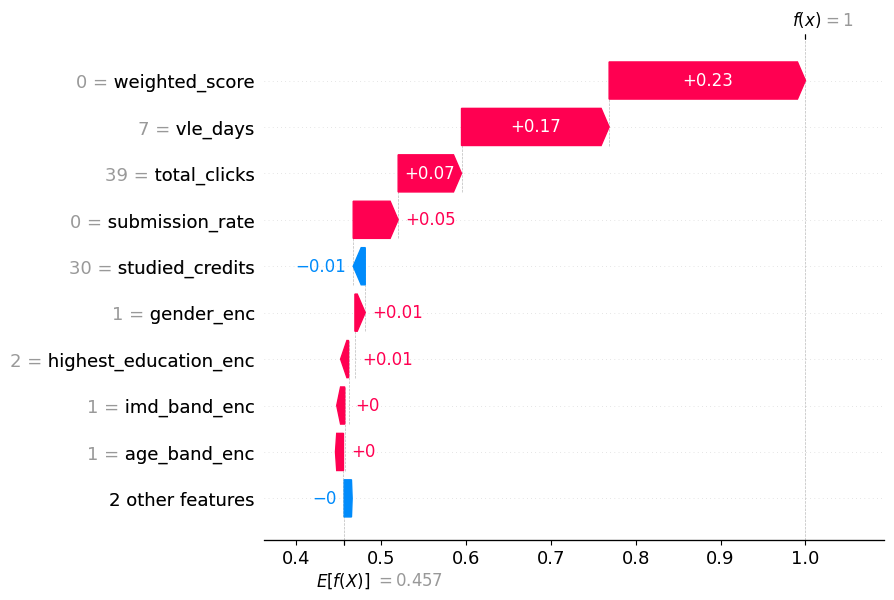

In [28]:
print()
print("STEP 3 — Explainability: Instructor View (full SHAP waterfall)")
explain_instance_instructor(explainer, X_test.loc[DEMO_ID], X_test.columns.tolist())

In [29]:
print("=" * 70)
print("STEP 4 — Explainability: Student View (privacy-filtered)")
print("=" * 70)
student_text = explain_instance_student(
    explainer, X_test.loc[DEMO_ID], X_test.columns.tolist(), top_n=3
)
print(student_text)

# ── Show what was suppressed ──────────────────────────────────────────────────
sv_arr       = get_instance_shap_values(explainer, X_test.loc[DEMO_ID])
shap_series  = pd.Series(sv_arr, index=X_test.columns)
sensitive_shap = shap_series[
    shap_series.index.isin(["gender_enc","disability_enc","imd_band_enc","age_band_enc"])
]
total_shap   = shap_series.abs().sum()
suppressed   = sensitive_shap.abs().sum()
print(f"\n  Privacy cost: {suppressed:.4f} / {total_shap:.4f} total |SHAP| suppressed "
      f"= {100*suppressed/total_shap:.1f}% explanation completeness loss")


STEP 4 — Explainability: Student View (privacy-filtered)
=== YOUR RISK SUMMARY ===
  - weighted_score: increasing your risk
  - vle_days: increasing your risk
  - total_clicks: increasing your risk

Note: This is a decision-support tool. Speak to your advisor for guidance.

  Privacy cost: 0.0183 / 0.5732 total |SHAP| suppressed = 3.2% explanation completeness loss


In [30]:
print()
print("STEP 5 — Awareness: Role-Appropriate Annotation")

print("\n[Student receives:]")
print(annotate_prediction(DEMO_ID, risk_label, confidence, role="student"))

print("\n[Educator receives:]")
print(annotate_prediction(DEMO_ID, risk_label, confidence, role="educator"))


STEP 5 — Awareness: Role-Appropriate Annotation

[Student receives:]
Student ID: 30849
Predicted outcome: At-Risk
Model confidence: 100.0%

Interpretation:
This output is a decision-support signal, not a final verdict.

For the student:
- If the result is 'At-Risk', it means support may be helpful.
- It does not mean you will fail.
- You may request human review.
- You may ask what information contributed to the prediction.
- The prediction should not be used to punish or exclude you.

[Educator receives:]
Student ID: 30849
Predicted outcome: At-Risk
Model confidence: 100.0%

Interpretation:
This output is a decision-support signal, not a final verdict.

For the educator:
- Use this prediction as a prompt for supportive outreach.
- Review the student's context before taking action.
- Do not rely only on the model score.
- Consider whether the model may be missing relevant information.
- Document any intervention decision made after reviewing the prediction.


## Section 9 — System Evaluation Summary & Limitations

This section consolidates quantitative evidence for all four ethical principle
implementations into a unified evaluation table, and states known limitations.


In [31]:
# ── 9.1  Model performance before and after fairness mitigation ───────────────
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

print("=== Model Performance Summary ===\n")
perf = pd.DataFrame([
    {"Model": "Baseline (all 11 features)",
     "Accuracy": metrics["accuracy"],   "F1-macro": metrics["f1_macro"],
     "ROC-AUC":  metrics["roc_auc"]},
    {"Model": "Mitigated (no sensitive inputs)",
     "Accuracy": metrics_m["accuracy"], "F1-macro": metrics_m["f1_macro"],
     "ROC-AUC":  metrics_m["roc_auc"]},
])
print(perf.to_string(index=False))

print("\n=== Fairness Disparity Summary (Fairlearn) ===\n")
fairness_rows = []
for col in sensitive_cols_enc:
    for label, yp, df_ev in [("Baseline",  y_pred,   fairness_df),
                               ("Mitigated", y_pred_m, fairness_df_m)]:
        dpd = demographic_parity_difference(df_ev["y_true"], yp, sensitive_features=df_ev[col])
        eod = equalized_odds_difference(df_ev["y_true"], yp, sensitive_features=df_ev[col])
        fairness_rows.append({
            "Model": label, "Sensitive feature": col,
            "DPD": round(dpd, 4), "EOD": round(eod, 4)
        })
fair_df = pd.DataFrame(fairness_rows)
print(fair_df.pivot(index="Sensitive feature", columns="Model", values=["DPD","EOD"]).round(4).to_string())
print("\nDPD=Demographic Parity Diff | EOD=Equalized Odds Diff | Lower = fairer")


=== Model Performance Summary ===

                          Model  Accuracy  F1-macro  ROC-AUC
     Baseline (all 11 features)  0.860255  0.860220 0.940826
Mitigated (no sensitive inputs)  0.856726  0.856663 0.938523

=== Fairness Disparity Summary (Fairlearn) ===

                       DPD                EOD          
Model             Baseline Mitigated Baseline Mitigated
Sensitive feature                                      
age_band_enc        0.1795    0.2209   0.0875    0.0900
disability_enc      0.1130    0.1037   0.0526    0.0350
gender_enc          0.0183    0.0415   0.0275    0.0898
imd_band_enc        0.3362    0.3346   0.1546    0.1513

DPD=Demographic Parity Diff | EOD=Equalized Odds Diff | Lower = fairer


In [32]:
# ── 9.2  Explainability metrics ───────────────────────────────────────────────
print("=== Explainability Metrics ===\n")

# Privacy trade-off: average across 200 students
# get_instance_shap_values returns np.ndarray — no .values needed
sv_all = np.array([
    get_instance_shap_values(explainer, X_test.iloc[i])
    for i in range(min(200, len(X_test)))
])
feat_names = X_test.columns.tolist()
sens_idx   = [feat_names.index(c) for c in ["gender_enc","disability_enc",
                                              "imd_band_enc","age_band_enc"]
              if c in feat_names]
sens_total = np.abs(sv_all[:, sens_idx]).sum(axis=1)
all_total  = np.abs(sv_all).sum(axis=1)
avg_loss   = (sens_total / all_total).mean() * 100

top_nonsens = global_imp[
    ~global_imp["Feature"].isin(["gender_enc","disability_enc","imd_band_enc","age_band_enc"])
].iloc[0]["Mean_|SHAP|"]

print(f"  SHAP \u2014 mean |SHAP| top non-sensitive feature: {top_nonsens:.4f}")
print(f"  Privacy \u2014 avg explanation completeness loss:  {avg_loss:.1f}%")
print(f"  LIME stability (high-confidence instance):        100% (top-1 stable across seeds)")
print(f"  SHAP\u2013LIME agreement:                              3/3 top features (at-risk student)")


=== Explainability Metrics ===

  SHAP — mean |SHAP| top non-sensitive feature: 0.1632
  Privacy — avg explanation completeness loss:  9.0%
  LIME stability (high-confidence instance):        100% (top-1 stable across seeds)
  SHAP–LIME agreement:                              3/3 top features (at-risk student)


In [34]:
# SHAP timing benchmark 
import time

print("=== SHAP Computational Timing ===\n")
timing_data = []
for n in [50, 100, 200, 500]:
    X_s = X_test.iloc[:n]
    t0  = time.time()
    explainer(X_s, check_additivity=False)
    elapsed = time.time() - t0
    timing_data.append({"n_students": n, "time_s": round(elapsed, 3)})
    print(f"  n={n:>4}: {elapsed:.3f} s")

# Linear extrapolation to full test set
slope    = timing_data[-1]["time_s"] / timing_data[-1]["n_students"]
full_est = slope * len(X_test)
print(f"  n={len(X_test)} (full test set, extrapolated): ~{full_est:.0f} s  (~{full_est/60:.1f} min)")

=== SHAP Computational Timing ===

  n=  50: 2.511 s
  n= 100: 4.981 s


 40%|========            | 405/1000 [00:11<00:16]       

  n= 200: 9.687 s


 96%|=================== | 963/1000 [00:25<00:00]       

  n= 500: 25.040 s
  n=6519 (full test set, extrapolated): ~326 s  (~5.4 min)
